In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np 
%matplotlib inline


In [2]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2)

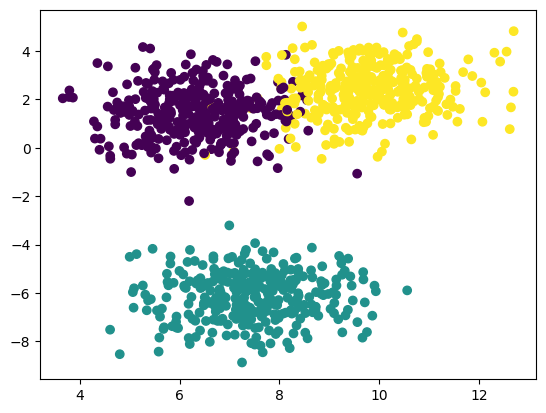

In [3]:
#    
plt.scatter(X[:, 0], X[:,1], c=y)

[1340.0000000000011, 697.0167108406285, 260.3214121450789, 207.7368518751723, 175.44707801269283, 122.92433368760739, 103.5054915785685, 88.29438371862724, 81.67551381827137, 76.10330309743537]


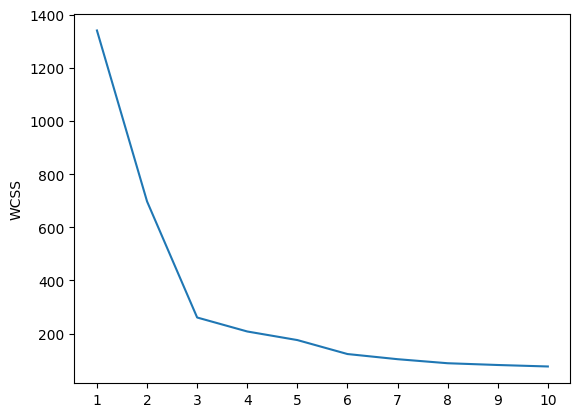

In [5]:
##perform standardization -- feature scaling techniques

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.33, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.cluster import KMeans

##elbow method to select k value

wcss = [] 
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, init = "k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

print(wcss)

##plot elbow cjurve 

plt.plot(range(1,11),wcss)

plt.xticks(range(1,11))

plt.ylabel("WCSS")
plt.show()


In [7]:
kmeans = KMeans(n_clusters=3, init="k-means++")
kmeans.fit_predict(X_train_scaled)



array([2, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2, 1, 2, 0, 1, 0, 1,
       1, 0, 0, 1, 2, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 2, 0, 0, 0, 0, 2,
       2, 2, 2, 2, 2, 0, 1, 2, 2, 0, 1, 1, 1, 1, 2, 1, 1, 0, 1, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 0, 0,
       2, 1, 1, 1, 2, 1, 0, 0, 2, 2, 0, 1, 2, 1, 2, 2, 2, 1, 1, 1, 2, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 2, 2, 1, 2, 0, 2, 0, 1, 1, 0, 0, 1, 2, 0,
       2, 1, 1, 1, 2, 0, 1, 2, 2, 1, 2, 0, 1, 0, 1, 2, 0, 2, 0, 0, 1, 0,
       2, 1, 0, 2, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 0, 0, 0, 2, 0, 1, 1,
       0, 2, 2, 2, 2, 2, 2, 0, 1, 0, 0, 1, 1, 0, 2, 0, 1, 1, 1, 2, 1, 1,
       0, 2, 0, 2, 0, 0, 1, 0, 2, 1, 0, 2, 0, 0, 0, 1, 0, 2, 2, 1, 0, 2,
       2, 0, 1, 0, 1, 0, 2, 1, 2, 0, 0, 0, 0, 2, 2, 1, 2, 0, 0, 1, 1, 2,
       2, 1, 0, 1, 2, 0, 0, 0, 0, 0, 1, 1, 0, 0, 2, 1, 1, 1, 1, 0, 0, 2,
       2, 2, 0, 2, 2, 1, 2, 1, 0, 2, 0, 1, 0, 1, 1, 1, 0, 2, 2, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 2, 2, 2, 1, 1, 1, 2, 1,

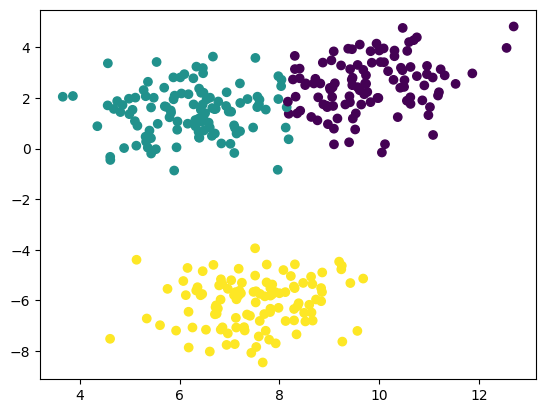

In [10]:
y_pred = kmeans.predict(X_test_scaled)
y_pred

plt.scatter(X_test[:,0], X_test[:,1], c=y_pred)

In [16]:
##validating the k value 
##knee loactor
##silhoutee scoring


#knee locator
# !pip install kneed

from kneed import KneeLocator

kl = KneeLocator(range(1,11), wcss,curve="convex", direction="decreasing")
kl.elbow


##silhoute score

from sklearn.metrics import silhouette_score

silhouette_coefficients=[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

    print(silhouette_coefficients)


[0.4549957528142678]
[0.4549957528142678, 0.6050882247713735]
[0.4549957528142678, 0.6050882247713735, 0.5318467017192416]
[0.4549957528142678, 0.6050882247713735, 0.5318467017192416, 0.47218914635989967]
[0.4549957528142678, 0.6050882247713735, 0.5318467017192416, 0.47218914635989967, 0.413237137977968]
[0.4549957528142678, 0.6050882247713735, 0.5318467017192416, 0.47218914635989967, 0.413237137977968, 0.4086143127753653]
[0.4549957528142678, 0.6050882247713735, 0.5318467017192416, 0.47218914635989967, 0.413237137977968, 0.4086143127753653, 0.3991643999894813]
[0.4549957528142678, 0.6050882247713735, 0.5318467017192416, 0.47218914635989967, 0.413237137977968, 0.4086143127753653, 0.3991643999894813, 0.38303758490281076]
[0.4549957528142678, 0.6050882247713735, 0.5318467017192416, 0.47218914635989967, 0.413237137977968, 0.4086143127753653, 0.3991643999894813, 0.38303758490281076, 0.35675452915320593]


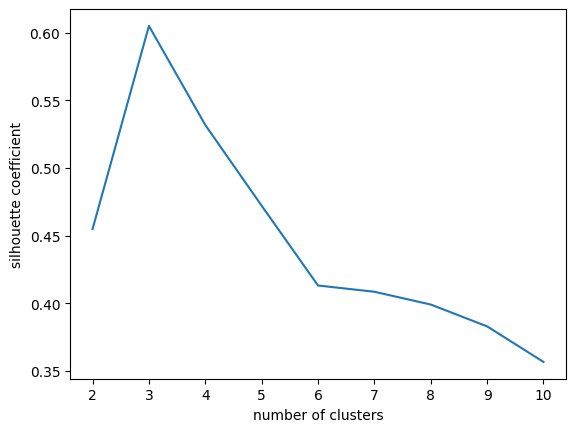

In [17]:
##plotting the silhouette score

plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("number of clusters")
plt.ylabel("silhouette coefficient")
plt.show()